In [ ]:
# get cosmos field coordinates
# tesselate in in 5 arcmin circles
# get a function to cone serach centered in the tesselation center


In [145]:
# import dotenv

# from babamul.api import get_alerts, get_profile, search_objects
from babamul.api import get_alerts, get_object, get_profile, search_objects

import os
import babamul

# Set your Kafka credentials (or even better, export these as env vars)
os.environ["BABAMUL_KAFKA_USERNAME"] = "babamul-099c4ecc-cecc-48ce-b13c-2f8ec91810f4"
os.environ["BABAMUL_KAFKA_PASSWORD"] = "U1tsgC89ZJScpdaYNNz1v1wvO0R6Lwzq"

# The API token is technically optional, but highly recommended for API access 
# (e.g. fetch and display cutouts). You can create API tokens in your profile page.
os.environ["BABAMUL_API_TOKEN"] = "bbml_feugeDrze708gRl05GlDGBLjfNjM3Ujs8stv"


# dotenv.load_dotenv()

# The token is read automatically from the BABAMUL_API_TOKEN env var.

In [146]:
profile = get_profile()

print(f"Username: {profile.username}")
print(f"Email:    {profile.email}")
print(f"ID:       {profile.id}")


Username: tomas.ahumada
Email:    tomas.ahumada@noirlab.edu
ID:       6582e919-614e-45a7-aa24-04185b262757


In [160]:
import numpy as np
import matplotlib.pyplot as plt

def generate_cosmos_tessellation(radius_arcmin=5.0, field_width_deg=1.4, field_height_deg=1.4):
    """
    Generates a hexagonal grid of coordinates to completely cover the COSMOS field.
    """
    # COSMOS center (J2000)
    ra_center = 150.11916667  # 10:00:28.600
    dec_center = 2.20583333   # +02:12:21.00
    
    # Convert radius to degrees
    r_deg = radius_arcmin / 60.0
    
    # For full coverage without gaps, spacing between centers is sqrt(3) * R
    # (If you only want circles to touch and leave gaps, change this to 2.0 * r_deg)
    d = np.sqrt(3) * r_deg  
    
    # Hex grid spacing geometry
    dx = d
    dy = d * (np.sqrt(3) / 2.0)
    
    # Determine boundary limits (correcting RA width for Dec projection)
    cos_dec_center = np.cos(np.radians(dec_center))
    ra_min = ra_center - (field_width_deg / 2.0) / cos_dec_center
    ra_max = ra_center + (field_width_deg / 2.0) / cos_dec_center
    dec_min = dec_center - (field_height_deg / 2.0)
    dec_max = dec_center + (field_height_deg / 2.0)
    
    # Estimate grid steps needed
    x_steps = int(np.ceil((ra_max - ra_min) / dx)) + 2
    y_steps = int(np.ceil((dec_max - dec_min) / dy)) + 2
    
    pointings = []
    
    # Generate the grid
    for i in range(-y_steps, y_steps):
        dec = dec_center + i * dy
        
        # Skip row if it falls completely outside our target box
        if not (dec_min - r_deg <= dec <= dec_max + r_deg):
            continue
            
        # Offset every other row for the nested hexagonal pattern
        x_offset = (dx / 2.0) if (i % 2 != 0) else 0.0
        
        # Calculate spherical projection correction at this specific Declination
        cos_dec = np.cos(np.radians(dec))
        
        for j in range(-x_steps, x_steps):
            # Apply cosine correction to Right Ascension spacing
            ra_shift = (j * dx + x_offset) / cos_dec
            ra = ra_center + ra_shift
            
            # Keep pointing if it touches the defined boundary
            if ra_min - r_deg <= ra <= ra_max + r_deg:
                pointings.append((ra, dec))
                
    return np.array(pointings), r_deg

pointings,r_deg = generate_cosmos_tessellation(radius_arcmin=5.0, field_width_deg=1.4, field_height_deg=1.4)

137

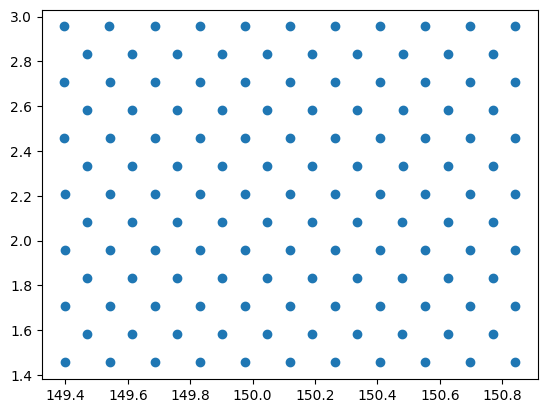

Skipping object 313963406732296210 due to API error: Request failed: timed out
Skipping object 170050494971510875 due to API error: Request failed: timed out
Skipping object 170054965090844700 due to API error: Request failed: timed out
Skipping object 313875415088758805 due to API error: Request failed: timed out
Skipping object 170032915669844088 due to API error: Request failed: timed out
Skipping object 313994140600762379 due to API error: Request failed: timed out
Skipping object 313893021479862374 due to API error: Request failed: timed out
Skipping object 314003013710118945 due to API error: Request failed: timed out
Skipping object 313871015676477587 due to API error: Request failed: timed out
Skipping object 313967767219863568 due to API error: Request failed: timed out


In [163]:
plt.scatter(*pointings.T)
len(pointings)

In [149]:
# Cone search for LSST alerts around a specific position
ra = 185.025830
dec = 8.410314
radius_arcsec = 300

cone_alerts = get_alerts("LSST", ra=ra, dec=dec, radius_arcsec=radius_arcsec)
print(
    f"Found {len(cone_alerts)} LSST alerts within {radius_arcsec} arcsec of (RA={ra:.5f}, Dec={dec:.5f})"
)

# Show unique objects in this region
unique_objects = {a.objectId for a in cone_alerts}
# print(f"Unique objects: {unique_objects}")
print(f'Retrieving {len(unique_objects)} objects ')


Found 3210 LSST alerts within 300 arcsec of (RA=185.02583, Dec=8.41031)
Retrieving 333 objects 


In [111]:
# a.candidate.ndethist
# all_alerts = get_alerts("LSST", object_id='170050509299778907')
# obj = get_object("LSST", object_id='170050509299778907')
# obj.candidate.ndethist

In [150]:

objects = []
for obj_id in unique_objects:
    # Get all alerts first
    obj = get_object("LSST", object_id=obj_id)
    # print(f"All alerts: {obj.candidate.ndethist}")
    
    if obj.candidate.ndethist != None and obj.candidate.ndethist > 10:
        objects.append(obj.objectId)
        

print(f'objects to use {len(objects)} out of {len(unique_objects)}')
print(f'{round(len(objects)/len(unique_objects)*100)} % objects used')
# objects

objects to use 50 out of 333
15 % objects used


In [153]:

alert.objectId

'170028526577123450'

In [154]:
import pandas as pd

# Your parameters (Note: double-check if 'magpfs' should be 'magpsf', as that's standard for Point Spread Function magnitudes!)
params2save = [
    'diaSourceId', 'isDipole', 'isdiffpos', 'glint_trail',
    'shape_flag', 'centroid_flag', 'psfFlux_flag', 'apFlux_flag',
    'pixelFlags_streak', 'pixelFlags_cr', 'pixelFlags_bad',
    'pixelFlags_saturated', 'pixelFlags_nodata', 'reliability',
    'extendedness', 'snr_psf', 'trailFlux', 'psfChi2', 'psfNdata'
]


rows = []

for obj in objects:
    all_alerts = get_alerts("LSST", object_id = obj)
    
    for alert in all_alerts:
        row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
        row_data['objectID'] = alert.objectId
        rows.append(row_data)
    

df = pd.DataFrame(rows)

df

,diaSourceId,isDipole,isdiffpos,glint_trail,shape_flag,centroid_flag,psfFlux_flag,apFlux_flag,pixelFlags_streak,pixelFlags_cr,pixelFlags_bad,pixelFlags_saturated,pixelFlags_nodata,reliability,extendedness,snr_psf,trailFlux,psfChi2,psfNdata,objectID
0,170032917784822325,True,False,False,True,False,False,False,False,False,False,False,False,0.209425,NaN,2.526200,NaN,2140.938965,1681,170028538416595090
1,170032918075277927,False,True,False,False,False,False,False,False,False,False,False,False,0.120326,0.542060,4.851726,1303.960693,1731.011963,1681,170028538416595090
2,170032918982295553,True,True,False,True,False,False,False,False,False,False,False,False,0.214016,NaN,4.140672,NaN,2136.052246,1681,170028538416595090
3,170032923153531132,True,False,False,True,False,False,False,False,False,False,False,False,0.252906,NaN,3.748877,NaN,2475.279785,1681,170028538416595090
4,170046108029943837,True,False,False,False,False,False,False,False,False,False,False,False,0.503210,0.751655,16.684780,-24813.328125,6356.984863,1681,170028538416595090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,170063716586357947,False,True,False,False,False,False,False,False,False,False,False,False,0.948138,0.062731,11.123835,2328.877686,1807.883057,1681,170028526577123450
2441,170063716721099434,False,True,False,False,False,False,False,False,False,False,False,False,0.771918,0.072073,8.484249,1964.004150,1755.250366,1681,170028526577123450
2442,170063716855316599,False,True,False,False,False,False,False,False,False,False,False,False,0.878571,0.261760,10.822856,2245.472412,1655.514038,1681,170028526577123450
2443,170063717127422666,False,True,False,False,False,False,False,False,False,False,False,False,0.920273,0.008769,10.142443,2239.993408,1785.554321,1681,170028526577123450


In [155]:

import pandas as pd

# Your parameters (Note: double-check if 'magpfs' should be 'magpsf', as that's standard for Point Spread Function magnitudes!)
params2save = [
    'diaSourceId', 'isDipole', 'isdiffpos', 'glint_trail',
    'shape_flag', 'centroid_flag', 'psfFlux_flag', 'apFlux_flag',
    'pixelFlags_streak', 'pixelFlags_cr', 'pixelFlags_bad',
    'pixelFlags_saturated', 'pixelFlags_nodata', 'reliability',
    'extendedness', 'snr_psf', 'trailFlux', 'psfChi2', 'psfNdata'
]

radius_arcsec = 300
rows = []


# cone search

ra = 185.025830
dec = 8.410314

cone_alerts = get_alerts("LSST", ra=ra, dec=dec, radius_arcsec=radius_arcsec)
print(
    f"Found {len(cone_alerts)} LSST alerts within {radius_arcsec} arcsec of (RA={ra:.5f}, Dec={dec:.5f})"
)

# Show unique objects in this region
unique_objects = {a.objectId for a in cone_alerts}
print(f'Retrieving {len(unique_objects)} objects ')

objects = []
for obj_id in unique_objects:
    obj = get_object("LSST", object_id=obj_id)
    
    if obj.candidate.ndethist != None and obj.candidate.ndethist > 10:
        objects.append(obj.objectId)

print(f'objects to use {len(objects)} out of {len(unique_objects)}')
print(f'{round(len(objects)/len(unique_objects)*100)} % objects used')

for obj in objects:
    all_alerts = get_alerts("LSST", object_id = obj)
    
    for alert in all_alerts:
        row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
        row_data['objectID'] = alert.objectId
        rows.append(row_data)
    

df = pd.DataFrame(rows)

df
# 

Found 3210 LSST alerts within 300 arcsec of (RA=185.02583, Dec=8.41031)
Retrieving 333 objects 
objects to use 50 out of 333
15 % objects used


,diaSourceId,diaObject,isDipole,isdiffpos,glint_trail,shape_flag,centroid_flag,psfFlux_flag,apFlux_flag,pixelFlags_streak,...,pixelFlags_bad,pixelFlags_saturated,pixelFlags_nodata,reliability,extendedness,snr_psf,trailFlux,psfChi2,psfNdata,objectID
0,170032917784822325,None,True,False,False,True,False,False,False,False,...,False,False,False,0.209425,NaN,2.526200,NaN,2140.938965,1681,170028538416595090
1,170032918075277927,None,False,True,False,False,False,False,False,False,...,False,False,False,0.120326,0.542060,4.851726,1303.960693,1731.011963,1681,170028538416595090
2,170032918982295553,None,True,True,False,True,False,False,False,False,...,False,False,False,0.214016,NaN,4.140672,NaN,2136.052246,1681,170028538416595090
3,170032923153531132,None,True,False,False,True,False,False,False,False,...,False,False,False,0.252906,NaN,3.748877,NaN,2475.279785,1681,170028538416595090
4,170046108029943837,None,True,False,False,False,False,False,False,False,...,False,False,False,0.503210,0.751655,16.684780,-24813.328125,6356.984863,1681,170028538416595090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2440,170063716586357947,None,False,True,False,False,False,False,False,False,...,False,False,False,0.948138,0.062731,11.123835,2328.877686,1807.883057,1681,170028526577123450
2441,170063716721099434,None,False,True,False,False,False,False,False,False,...,False,False,False,0.771918,0.072073,8.484249,1964.004150,1755.250366,1681,170028526577123450
2442,170063716855316599,None,False,True,False,False,False,False,False,False,...,False,False,False,0.878571,0.261760,10.822856,2245.472412,1655.514038,1681,170028526577123450
2443,170063717127422666,None,False,True,False,False,False,False,False,False,...,False,False,False,0.920273,0.008769,10.142443,2239.993408,1785.554321,1681,170028526577123450


In [156]:
# df

In [164]:
import pandas as pd

params2save = [
    'diaSourceId', 'isDipole', 'isdiffpos', 'glint_trail',
    'shape_flag', 'centroid_flag', 'psfFlux_flag', 'apFlux_flag',
    'pixelFlags_streak', 'pixelFlags_cr', 'pixelFlags_bad',
    'pixelFlags_saturated', 'pixelFlags_nodata', 'reliability',
    'extendedness', 'snr_psf', 'trailFlux', 'psfChi2', 'psfNdata','magpsf'
]

radius_arcsec = 300
rows = []

for ra,dec in pointings:
    
    # cone search
    try: 
        cone_alerts = get_alerts("LSST", ra=ra, dec=dec, radius_arcsec=radius_arcsec)
        print(
            f"Found {len(cone_alerts)} LSST alerts within {radius_arcsec} arcsec of (RA={ra:.5f}, Dec={dec:.5f})"
        )
        
        # Show unique objects in this region
        unique_objects = {a.objectId for a in cone_alerts}
        print(f'Retrieving {len(unique_objects)} objects ')
        
        objects = []
        for obj_id in unique_objects:
            obj = get_object("LSST", object_id=obj_id)
            
            if obj.candidate.ndethist != None and obj.candidate.ndethist > 10:
                objects.append(obj.objectId)
        
        print(f'objects to use {len(objects)} out of {len(unique_objects)}')
        print(f'{round(len(objects)/len(unique_objects)*100)} % objects used')
        
        for obj in objects:
            all_alerts = get_alerts("LSST", object_id = obj)
            
            for alert in all_alerts:
                row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
                row_data['objectID'] = alert.objectId
                rows.append(row_data)
    except Exception as e:
        # Catching the actual error 'e' helps debug API timeouts or unexpected data formats
        print(f"FAILED at RA={ra:.5f}, Dec={dec:.5f} | Error: {e}\n")
    
        
    
# df = pd.DataFrame(rows)

Found 8653 LSST alerts within 300 arcsec of (RA=149.39725, Dec=1.45583)
Retrieving 1387 objects 
Skipping object 170054950996934663 due to API error: Request failed: timed outSkipping object 170050501011308656 due to API error: Request failed: timed out

Skipping object 313893021640294526 due to API error: Request failed: timed out
Skipping object 170054956099829881 due to API error: Request failed: timed out
Skipping object 170050500609704088 due to API error: Request failed: timed out
Skipping object 314003015455473865 due to API error: Request failed: timed out
Skipping object 170050494301995110 due to API error: Request failed: timed out
Skipping object 170028514136293496 due to API error: Request failed: timed out
Skipping object 170059280328687670 due to API error: Request failed: timed out
Skipping object 314003014380683299 due to API error: Request failed: timed out
Skipping object 170046091020468340 due to API error: Request failed: [Errno 8] nodename nor servname provided, or

In [165]:
df = pd.DataFrame(rows)
df.to_csv('babamul_2.csv',index=False)
df

,diaSourceId,isDipole,isdiffpos,glint_trail,shape_flag,centroid_flag,psfFlux_flag,apFlux_flag,pixelFlags_streak,pixelFlags_cr,...,pixelFlags_saturated,pixelFlags_nodata,reliability,extendedness,snr_psf,trailFlux,psfChi2,psfNdata,magpsf,objectID
0,170028517762269188,False,True,False,True,True,True,True,False,False,...,False,False,0.310480,NaN,14.148404,NaN,1353.333740,1558,22.734301,313888627059327063
1,170032899836870745,True,True,False,True,False,False,False,False,False,...,False,False,0.213171,NaN,9.573616,NaN,2835.705078,1681,22.324696,313888627059327063
2,170032899993632792,False,True,False,True,True,True,True,False,False,...,False,False,0.222810,NaN,25.803537,NaN,2534.842041,1681,21.412580,313888627059327063
3,170032900106354838,True,True,False,False,False,False,False,False,False,...,False,False,0.131109,0.438026,11.494576,8862.450195,2557.539307,1681,22.117939,313888627059327063
4,170032900241096729,True,True,False,False,False,False,False,False,False,...,False,False,0.136720,0.380691,10.382855,9217.496094,3556.637207,1681,22.234726,313888627059327063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154030,170050502649184319,True,True,False,False,False,False,False,False,False,...,False,False,0.173843,0.877344,1.755275,1594.640015,1905.387939,1681,24.555094,313998569371074584
154031,170050503054983278,True,False,False,True,False,False,False,False,False,...,False,False,0.193594,NaN,0.638073,NaN,2074.664551,1681,25.661678,313998569371074584
154032,170050503187103762,True,True,False,True,False,False,False,False,False,...,False,False,0.136500,NaN,0.811301,NaN,1913.915771,1681,25.413332,313998569371074584
154033,170050503322370060,True,True,False,True,False,False,False,False,True,...,False,False,0.172936,NaN,2.457811,NaN,2019.914673,1681,24.203934,313998569371074584


In [166]:
skipped_ids = [
    '170028500579778663', '170028510534434821', '170028510778753108', '170028510910349430', 
    '170028510938661013', '170028512553467992', '170028512635256894', '170028512922042441', 
    '170028513082998857', '170028513192575006', '170028514136293496', '170028516299505682', 
    '170028516398071945', '170028517489639555', '170028517624905851', '170028520283045957', 
    '170028526097399926', '170032900079616136', '170032901846990980', '170032903029784624', 
    '170032903281967140', '170032903435583567', '170032903969308811', '170032904240365612', 
    '170032906028187677', '170032906519969873', '170032906790502537', '170032907729502429', 
    '170032909203275778', '170032909228441819', '170032909742768245', '170032909742768323', 
    '170032909900578839', '170032910010679381', '170032914463457351', '170032915647823937', 
    '170032915668271200', '170046090910367754', '170046090926096392', '170046091020468340', 
    '170046091958419585', '170046092736462861', '170046092761628689', '170046093412794384', 
    '170046093433241685', '170046100413087880', '170046101888434308', '170046104036966473', 
    '170046104336335024', '170046105374949435', '170046105381765201', '170046105893994618', 
    '170046118958202929', '170050488424202320', '170050489632686091', '170050491260076098', 
    '170050491376467969', '170050492421374019', '170050493789765772', '170050494301995110', 
    '170050494412619909', '170050494434639918', '170050494676860955', '170050494837293065', 
    '170050494838866066', '170050495400378417', '170050495532499039', '170050495532499090', 
    '170050497008369697', '170050497365934248', '170050497368031427', '170050497656914061', 
    '170050497679982710', '170050497685225476', '170050497795850424', '170050498059042910', 
    '170050498569175048', '170050498596438037', '170050498751103092', '170050498861727799', 
    '170050499535962341', '170050500609704088', '170050501011308656', '170050502087147547', 
    '170050503003603035', '170054942039998512', '170054943884968081', '170054950996934663', 
    '170054951940653176', '170054954111205412', '170054956099829881', '170054956234047635', 
    '170054958090027143', '170054973528735800', '170054973800317008', '170054974731976762', 
    '170054979548086329', '170054981043879995', '170054989081215023', '170059280328687670', 
    '170059281533501558', '170059284734279739', '170059290374045802', '170059290640908434', 
    '170059291312521266', '170059293190520882', '170059294152589448', '170059294532173842', 
    '170059298175975429', '170059298828714021', '170059301510447108', '170107661278773285', 
    '313853533169909883', '313853533570990120', '313853533705732112', '313853533724082248', 
    '313853533815308336', '313862203237728356', '313871013149933683', '313871014309134506', 
    '313871014332203098', '313871015540686900', '313871016460288109', '313875416406818836', 
    '313875416811044871', '313888627218710640', '313888627219234933', '313888627346636990', 
    '313888627348209701', '313893021477765223', '313893021479338039', '313893021479862384', 
    '313893021503979572', '313893021640294526', '313893021776084999', '313928194999713808', 
    '313967766547726355', '313967767084597497', '313972182557917277', '313972182580461621', 
    '313972183229530158', '313972184189501448', '313972184597397569', '313976545950564358', 
    '313976546127249417', '313980947912982657', '313980948047200297', '313980948429406276', 
    '313980948452999193', '313980948473446543', '313980948740833283', '313985344884178959', 
    '313985345018396674', '313985345531674648', '313985345559461890', '313985345691582488', 
    '313994140732882951', '313998534623363104', '313998534866632731', '313998535022346258', 
    '313998535026016278', '313998569067511826', '313998569204875301', '313998569337520238', 
    '313998569740173394', '313998569762193564', '313998570008084491', '313998570275995775', 
    '314003013978554378', '314003014380683299', '314003014490783822', '314003014492356630', 
    '314003014513852476', '314003014537969703', '314003014648594440', '314003014760792089', 
    '314003014893436973', '314003014895009807', '314003015028178973', '314003015029751834', 
    '314003015316013080', '314003015319683113', '314003015433453716', '314003015433453802', 
    '314003015433453858', '314003015433453881', '314003015453900831', '314003015455473865', 
    '314003015457046953', '314003015477493944', '314003015478018061', '314003015478018310', 
    '314003015478018440', '314003015478018472', '314003015481163889', '314003015481163946', 
    '314007378984960122', '314007378986532887', '314007379164266561', '314007379165839389', 
    '314007379253395519', '314011775824035851', '314011776359333977', '314011777188233235', 
    '314011790662434876', '314011790662959203', '314046942058381367', 'sso21164728286393674'
]

In [167]:
for obj in skipped_ids:
    all_alerts = get_alerts("LSST", object_id = obj)
    
    for alert in all_alerts:
        row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
        row_data['objectID'] = alert.objectId
        rows.append(row_data)

In [170]:
df = pd.DataFrame(rows)
df.to_csv('babamul_2.csv',index=False)
len(rows)

156511

In [171]:
failed_pointings = [
    (149.39652, 2.95583), (149.39667, 2.70583), (149.39682, 2.45583), (149.39694, 2.20583), 
    (149.39706, 1.95583), (149.39716, 1.70583), (149.39725, 1.45583), (149.46885, 2.83083), 
    (149.46911, 2.33083), (149.46922, 2.08083), (149.46932, 1.83083), (149.46940, 1.58083), 
    (149.54105, 2.95583), (149.54117, 2.70583), (149.54129, 2.45583), (149.54139, 2.20583), 
    (149.54148, 1.95583), (149.54156, 1.70583), (149.54163, 1.45583), (149.61357, 2.33083), 
    (149.61365, 2.08083), (149.61373, 1.83083), (149.61379, 1.58083), (149.68576, 2.45583), 
    (149.68583, 2.20583), (149.68590, 1.95583), (149.68596, 1.70583), (149.68601, 1.45583), 
    (149.75788, 2.83083), (149.75802, 2.33083), (149.75808, 2.08083), (149.75814, 1.83083), 
    (149.75819, 1.58083), (149.83011, 2.95583), (149.83017, 2.70583), (149.83023, 2.45583), 
    (149.83028, 2.20583), (149.83032, 1.95583), (149.83036, 1.70583), (149.83040, 1.45583), 
    (149.90244, 2.58083), (149.90248, 2.33083), (149.90252, 2.08083), (149.90255, 1.83083), 
    (149.90258, 1.58083), (149.97467, 2.70583), (149.97470, 2.45583), (149.97472, 2.20583), 
    (149.97474, 1.95583), (149.97477, 1.70583), (149.97478, 1.45583), (150.04691, 2.83083), 
    (150.04694, 2.33083), (150.04695, 2.08083), (150.04696, 1.83083), (150.04697, 1.58083), 
    (150.11917, 1.45583), (150.11917, 1.70583), (150.11917, 1.95583), (150.11917, 2.20583), 
    (150.11917, 2.45583), (150.11917, 2.70583), (150.11917, 2.95583), (150.19136, 1.58083), 
    (150.19137, 1.83083), (150.19140, 2.33083), (150.19141, 2.58083), (150.19142, 2.83083), 
    (150.26355, 1.45583), (150.26357, 1.70583), (150.26359, 1.95583), (150.26361, 2.20583), 
    (150.26364, 2.45583), (150.33576, 1.58083), (150.33578, 1.83083), (150.33582, 2.08083), 
    (150.33585, 2.33083), (150.33589, 2.58083), (150.40794, 1.45583), (150.40797, 1.70583), 
    (150.40801, 1.95583), (150.40806, 2.20583), (150.40811, 2.45583), (150.40816, 2.70583), 
    (150.40823, 2.95583), (150.48015, 1.58083), (150.48019, 1.83083), (150.48025, 2.08083), 
    (150.48038, 2.58083), (150.48045, 2.83083), (150.55232, 1.45583), (150.55237, 1.70583), 
    (150.55243, 1.95583), (150.55266, 2.70583), (150.55276, 2.95583), (150.62454, 1.58083), 
    (150.62461, 1.83083), (150.62477, 2.33083), (150.63895, 1.45583), (150.69670, 1.45583), 
    (150.69677, 1.70583), (150.69685, 1.95583), (150.69705, 2.45583), (150.69716, 2.70583), 
    (150.76893, 1.58083), (150.76902, 1.83083), (150.76911, 2.08083), (150.76922, 2.33083), 
    (150.76948, 2.83083), (150.81221, 1.45583), (150.84109, 1.45583), (150.84117, 1.70583), 
    (150.84128, 1.95583), (150.84139, 2.20583), (150.84166, 2.70583), (150.84182, 2.95583)
]

import pandas as pd

params2save = [
    'diaSourceId', 'isDipole', 'isdiffpos', 'glint_trail',
    'shape_flag', 'centroid_flag', 'psfFlux_flag', 'apFlux_flag',
    'pixelFlags_streak', 'pixelFlags_cr', 'pixelFlags_bad',
    'pixelFlags_saturated', 'pixelFlags_nodata', 'reliability',
    'extendedness', 'snr_psf', 'trailFlux', 'psfChi2', 'psfNdata','magpsf'
]

radius_arcsec = 300
rows = []

for ra,dec in failed_pointings:
    
    # cone search
    try: 
        cone_alerts = get_alerts("LSST", ra=ra, dec=dec, radius_arcsec=radius_arcsec)
        print(
            f"Found {len(cone_alerts)} LSST alerts within {radius_arcsec} arcsec of (RA={ra:.5f}, Dec={dec:.5f})"
        )
        
        # Show unique objects in this region
        unique_objects = {a.objectId for a in cone_alerts}
        print(f'Retrieving {len(unique_objects)} objects ')
        
        objects = []
        for obj_id in unique_objects:
            obj = get_object("LSST", object_id=obj_id)
            
            if obj.candidate.ndethist != None and obj.candidate.ndethist > 10:
                objects.append(obj.objectId)
        
        print(f'objects to use {len(objects)} out of {len(unique_objects)}')
        print(f'{round(len(objects)/len(unique_objects)*100)} % objects used')
        
        for obj in objects:
            all_alerts = get_alerts("LSST", object_id = obj)
            
            for alert in all_alerts:
                row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
                row_data['objectID'] = alert.objectId
                rows.append(row_data)
    except Exception as e:
        # Catching the actual error 'e' helps debug API timeouts or unexpected data formats
        print(f"FAILED at RA={ra:.5f}, Dec={dec:.5f} | Error: {e}\n")
    
        
    
# df = pd.DataFrame(rows)

In [158]:
import pandas as pd
import concurrent.futures

params2save = [
    'diaSourceId', 'isDipole', 'isdiffpos', 'glint_trail',
    'shape_flag', 'centroid_flag', 'psfFlux_flag', 'apFlux_flag',
    'pixelFlags_streak', 'pixelFlags_cr', 'pixelFlags_bad',
    'pixelFlags_saturated', 'pixelFlags_nodata', 'reliability',
    'extendedness', 'snr_psf', 'trailFlux', 'psfChi2', 'psfNdata','magpsf'
]

radius_arcsec = 180

# 1. Wrap the core logic for a single pointing into a function
def process_pointing(pointing):
    ra, dec = pointing
    local_rows = []
    
    # 1. Outer Try/Except just for the Cone Search
    try: 
        cone_alerts = get_alerts("LSST", ra=ra, dec=dec, radius_arcsec=radius_arcsec)
        unique_objects = {a.objectId for a in cone_alerts}
    except Exception as e:
        print(f"CONE SEARCH FAILED at RA={ra:.5f}, Dec={dec:.5f} | Error: {e}")
        return local_rows # Bail out of this pointing entirely
        
    if len(unique_objects) == 0:
        return local_rows 
            
    objects = []
    for obj_id in unique_objects:
        # 2. Inner Try/Except for checking individual objects
        try:
            obj = get_object("LSST", object_id=obj_id)
            ndethist = getattr(obj.candidate, 'ndethist', None)
            if ndethist is not None and ndethist > 10:
                objects.append(obj.objectId)
        except Exception as e:
            # If one object fails, we just print a warning and keep going!
            print(f"Skipping object {obj_id} due to API error: {e}")
            continue
    
    for obj_id in objects:
        # 3. Inner Try/Except for getting the historical alerts
        try:
            all_alerts = get_alerts("LSST", object_id=obj_id)
            for alert in all_alerts:
                row_data = {param: getattr(alert.candidate, param, None) for param in params2save}
                row_data['objectID'] = alert.objectId

                local_rows.append(row_data)
        except Exception as e:
            # If one light curve has a bad 'magap', it only skips this one light curve
            print(f"Failed to extract alerts for {obj_id} | Error: {e}")
            continue
                
    return local_rows

# --- MAIN PARALLEL EXECUTION ---

all_rows = []

# You can adjust max_workers. 5 to 10 is usually a safe sweet spot for external APIs.
MAX_WORKERS = 10 

print(f"Starting parallel fetch with {MAX_WORKERS} workers...")

# 2. Launch the thread pool
with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    # Submit all pointings to the executor
    futures = [executor.submit(process_pointing, pt) for pt in pointings[0:20]]
    
    # As each thread finishes its pointing, grab the results
    for future in concurrent.futures.as_completed(futures):
        result_rows = future.result()
        # Extend the master list with the rows from this completed thread
        if result_rows:
            all_rows.extend(result_rows)

# 3. Build the final DataFrame
df = pd.DataFrame(all_rows)

print(f"\nFinished! Created DataFrame with {len(df)} total rows.")

Starting parallel fetch with 10 workers...
CONE SEARCH FAILED at RA=149.68601, Dec=1.45583 | Error: 2 validation errors for LsstAlert
candidate.magap
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type
candidate.sigmagap
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type
CONE SEARCH FAILED at RA=149.77264, Dec=1.45583 | Error: 2 validation errors for LsstAlert
candidate.magap
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type
candidate.sigmagap
  Input should be a valid number [type=float_type, input_value=None, input_type=NoneType]
    For further information visit https://errors.pydantic.dev/2.12/v/float_type


KeyboardInterrupt: 

In [ ]:
all_rows

In [77]:
params2save = ['diaSourceId','isDipole','magpfs','psfChi2']

obj = get_object("LSST", object_id='170028527655059745')

In [97]:
# list(obj.candidate.dict().keys())
import pandas as pd

# Your parameters (Note: double-check if 'magpfs' should be 'magpsf', as that's standard for Point Spread Function magnitudes!)
params2save = ['diaSourceId', 
               # 'isDipole', 'magpsf', 'psfChi2']

'isDipole',
'isdiffpos',
'glint_trail',
'shape_flag',
'centroid_flag',
'psfFlux_flag',
'apFlux_flag',
'pixelFlags_streak',
'pixelFlags_cr',
'pixelFlags_bad',
'pixelFlags_saturated',
'pixelFlags_nodata',


# Numeric:
'reliability',
'extendedness',
'snr_psf',
'trailFlux',
# Could also check the reduced chi2 which is 
'psfChi2',
'psfNdata',

              ]

# 1. Retrieve your object
obj = get_object("LSST", object_id='170028527655059745')

# 2. Extract the data using a dictionary comprehension and getattr()
# getattr(object, attribute_name, default_value)
row_data = {param: getattr(obj.candidate, param, None) for param in params2save}

# 3. Create the Pandas DataFrame
# We wrap row_data in a list so Pandas knows it's a single row of data
df = pd.DataFrame([row_data])

print(df)

          diaSourceId  isDipole  isdiffpos  glint_trail  shape_flag  \
0  170050511336112363      True      False        False        True   

   centroid_flag  psfFlux_flag  apFlux_flag  pixelFlags_streak  pixelFlags_cr  \
0          False         False        False              False          False   

   pixelFlags_bad  pixelFlags_saturated  pixelFlags_nodata  reliability  \
0           False                 False              False     0.287112   

  extendedness   snr_psf trailFlux      psfChi2  psfNdata  
0         None  0.458609      None  1741.162231      1681  


In [95]:
obj = get_object("LSST", object_id='170028527655059745')

all_alerts = get_alerts("LSST", object_id='170028527655059745')

# row_data = {param: getattr(all_alerts.candidate, param, None) for param in params2save}
len(all_alerts), obj.candidate.ndethist

(9, 11)

In [92]:
list(obj.candidate.model_dump().keys())

['diaSourceId',
 'visit',
 'detector',
 'diaObjectId',
 'ssObjectId',
 'parentDiaSourceId',
 'midpointMjdTai',
 'ra',
 'raErr',
 'dec',
 'decErr',
 'centroid_flag',
 'apFlux',
 'apFluxErr',
 'apFlux_flag',
 'apFlux_flag_apertureTruncated',
 'psfFlux',
 'psfFluxErr',
 'psfChi2',
 'psfNdata',
 'psfFlux_flag',
 'psfFlux_flag_edge',
 'psfFlux_flag_noGoodPixels',
 'trailFlux',
 'trailFluxErr',
 'trailRa',
 'trailRaErr',
 'trailDec',
 'trailDecErr',
 'trailLength',
 'trailLengthErr',
 'trailAngle',
 'trailAngleErr',
 'trailChi2',
 'trailNdata',
 'trail_flag_edge',
 'scienceFlux',
 'scienceFluxErr',
 'forced_PsfFlux_flag',
 'forced_PsfFlux_flag_edge',
 'forced_PsfFlux_flag_noGoodPixels',
 'templateFlux',
 'templateFluxErr',
 'shape_flag',
 'shape_flag_no_pixels',
 'shape_flag_not_contained',
 'shape_flag_parent_source',
 'extendedness',
 'reliability',
 'band',
 'isDipole',
 'pixelFlags',
 'pixelFlags_bad',
 'pixelFlags_cr',
 'pixelFlags_crCenter',
 'pixelFlags_edge',
 'pixelFlags_nodata',
 '